In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD

In [4]:
print("Memuat dataset pertama dan kedua...")

df1 = pd.read_csv("../../data/komdigi_hoaks.csv")
df2 = pd.read_csv("../../data/datasetUMPOHoax.csv")

print("Dataset Komdigi :", df1.shape)
print("Dataset UMPO    :", df2.shape)

Memuat dataset pertama dan kedua...
Dataset Komdigi : (4176, 13)
Dataset UMPO    : (4617, 6)


In [5]:
# Dataset Komdigi
df1['teks_gabungan'] = (
    df1['title'].fillna('') + " " +
    df1['excerpt'].fillna('')
)

df1_bersih = df1[['teks_gabungan']].copy()
df1_bersih['sumber'] = 'Komdigi'


# Dataset UMPO
df2_bersih = df2[['tweet']].copy()

df2_bersih = df2_bersih.rename(
    columns={'tweet': 'teks_gabungan'}
)

df2_bersih['sumber'] = 'UMPO'


print("Dataset Komdigi:")
print(df1_bersih.head())

print("\nDataset UMPO:")
print(df2_bersih.head())

Dataset Komdigi:
                                       teks_gabungan   sumber
0  [HOAKS] Tautan Pencairan BSU September 2026 Se...  Komdigi
1  [HOAKS] Panas El Nino Berkaitan dengan Gelomba...  Komdigi
2  [HOAKS] Susu Bebelac Berbahaya karena Mengandu...  Komdigi
3  [HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...  Komdigi
4  [HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...  Komdigi

Dataset UMPO:
                                       teks_gabungan sumber
0  Mahasiswa ITS buat pembangkit listrik dari kol...   UMPO
1  Lampu Dengan Sumber Energi Air Garam Ini Berpo...   UMPO
2  #didUknow Lampu LED yang menggunakan air dan g...   UMPO
3  #tekno Lampu Dengan Sumber Energi Air Garam In...   UMPO
4  Green House,lampu darurat dg sumber energi gar...   UMPO


In [6]:
# Menghapus baris kosong dari dataset Komdigi
df1_bersih = df1_bersih[
    df1_bersih['teks_gabungan'].str.strip() != ''
]

# Menghapus baris kosong dari dataset UMPO
df2_bersih = df2_bersih.dropna(
    subset=['teks_gabungan']
)

# Menggabungkan kedua dataset
df_gabungan = pd.concat(
    [df1_bersih, df2_bersih],
    ignore_index=True
)

print(
    f"Total data siap diproses: "
    f"{len(df_gabungan)} baris."
)

print("\nJumlah data berdasarkan sumber:")
print(df_gabungan['sumber'].value_counts())

Total data siap diproses: 8775 baris.

Jumlah data berdasarkan sumber:
sumber
UMPO       4599
Komdigi    4176
Name: count, dtype: int64


In [7]:
print("Menjalankan vektorisasi TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=1500,
    stop_words='english'
)

X = tfidf.fit_transform(
    df_gabungan['teks_gabungan']
)

print("Ukuran matriks TF-IDF:")
print(X.shape)

Menjalankan vektorisasi TF-IDF...
Ukuran matriks TF-IDF:
(8775, 1500)


In [8]:
eps = 0.3
min_samples = 10

print("Parameter DBSCAN:")
print("eps         :", eps)
print("min_samples :", min_samples)

Parameter DBSCAN:
eps         : 0.3
min_samples : 10


In [9]:
print("Melatih model DBSCAN...")

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='cosine'
)

df_gabungan['cluster'] = dbscan.fit_predict(X)

print("DBSCAN selesai.")

Melatih model DBSCAN...
DBSCAN selesai.


In [10]:
labels = sorted(
    df_gabungan['cluster'].unique()
)

# Jumlah cluster tanpa noise (-1)
n_clusters = len(
    set(labels) - {-1}
)

# Jumlah data noise
n_noise = (
    df_gabungan['cluster'] == -1
).sum()

print("\n" + "=" * 50)
print("HASIL DBSCAN")
print("=" * 50)

print(
    f"Jumlah cluster terbentuk : {n_clusters}"
)

print(
    f"Jumlah data noise        : {n_noise}"
)

print(
    f"Total data               : {len(df_gabungan)}"
)


HASIL DBSCAN
Jumlah cluster terbentuk : 11
Jumlah data noise        : 8186
Total data               : 8775


In [11]:
print("\nJumlah data setiap cluster:")

jumlah_cluster = (
    df_gabungan['cluster']
    .value_counts()
    .sort_index()
)

print(jumlah_cluster)


Jumlah data setiap cluster:
cluster
-1     8186
 0       81
 1       40
 2       32
 3       17
 4      352
 5       15
 6       10
 7       10
 8       11
 9       11
 10      10
Name: count, dtype: int64


In [12]:
print("Mereduksi dimensi data untuk visualisasi 2D...")

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_svd = svd.fit_transform(X)

df_gabungan['svd_x'] = X_svd[:, 0]
df_gabungan['svd_y'] = X_svd[:, 1]

print("Reduksi dimensi selesai.")

print(
    "Total explained variance:",
    f"{svd.explained_variance_ratio_.sum():.2%}"
)

Mereduksi dimensi data untuk visualisasi 2D...
Reduksi dimensi selesai.
Total explained variance: 2.50%


Membuat grafik clustering...


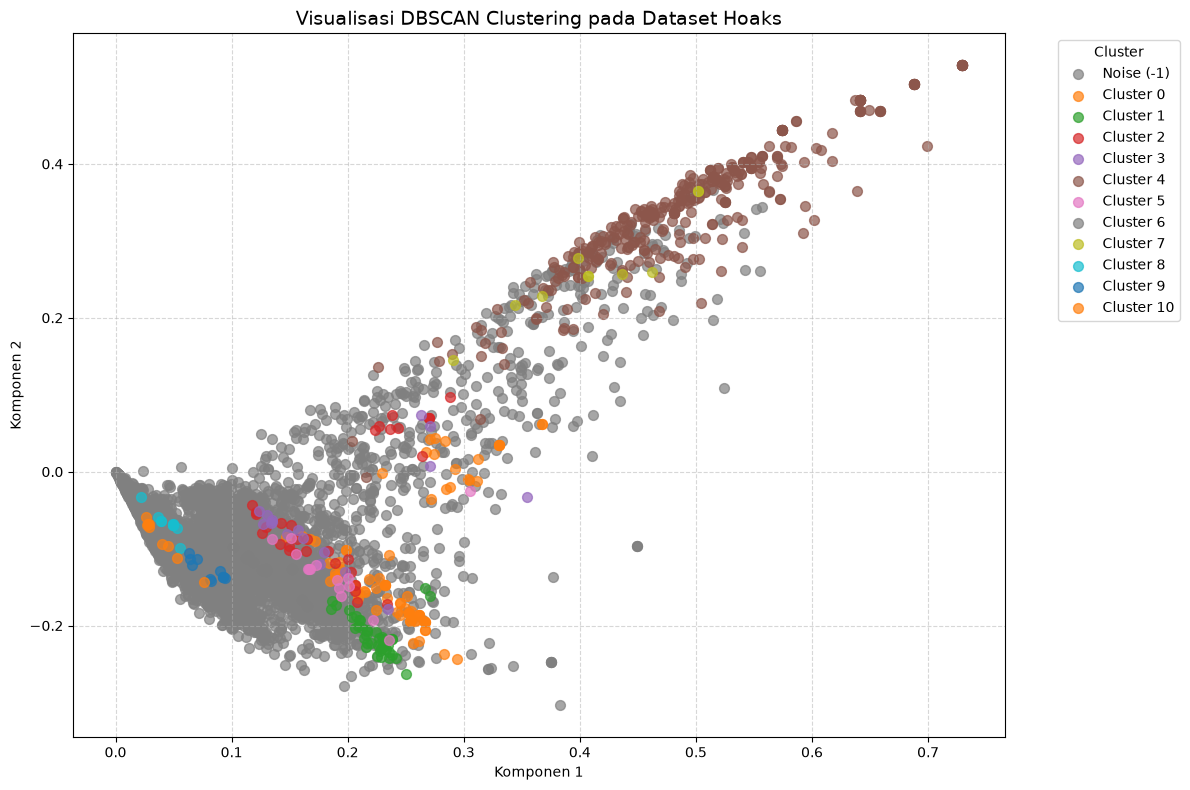

In [13]:
print("Membuat grafik clustering...")

plt.figure(figsize=(12, 8))

unique_labels = sorted(
    df_gabungan['cluster'].unique()
)

# Membuat warna
palette = sns.color_palette(
    "tab10",
    n_colors=max(len(unique_labels), 1)
)

# Plot setiap cluster
for i, label in enumerate(unique_labels):

    data_cluster = df_gabungan[
        df_gabungan['cluster'] == label
    ]

    # Noise diberi warna abu-abu
    if label == -1:
        warna = 'gray'
        nama = 'Noise (-1)'
    else:
        warna = palette[i % len(palette)]
        nama = f'Cluster {label}'

    plt.scatter(
        data_cluster['svd_x'],
        data_cluster['svd_y'],
        s=50,
        alpha=0.7,
        color=warna,
        label=nama
    )

plt.title(
    'Visualisasi DBSCAN Clustering pada Dataset Hoaks',
    fontsize=14
)

plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    'hasil_dbscan_2d.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [14]:
terms = tfidf.get_feature_names_out()

print("\n" + "=" * 60)
print("KATA KUNCI DOMINAN SETIAP CLUSTER")
print("=" * 60)

for label in unique_labels:

    if label == -1:
        cluster_name = "NOISE / OUTLIER"
    else:
        cluster_name = f"CLUSTER {label}"

    # Mengambil index data dalam cluster
    idx = df_gabungan[
        df_gabungan['cluster'] == label
    ].index

    if len(idx) == 0:
        continue

    # Mengambil data TF-IDF cluster
    cluster_tfidf = X[idx]

    # Menghitung rata-rata TF-IDF setiap kata
    cluster_mean = np.asarray(
        cluster_tfidf.mean(axis=0)
    ).flatten()

    # Mengambil 7 kata dengan nilai tertinggi
    top_term_indices = (
        cluster_mean
        .argsort()[::-1][:7]
    )

    top_terms = [
        terms[i]
        for i in top_term_indices
    ]

    print(
        f"\n[{cluster_name} - {len(idx)} data]"
    )

    print(
        "Kata Kunci:",
        ", ".join(top_terms)
    )


KATA KUNCI DOMINAN SETIAP CLUSTER

[NOISE / OUTLIER - 8186 data]
Kata Kunci: hoaks, di, dan, yang, untuk, http, dari

[CLUSTER 0 - 81 data]
Kata Kunci: lowongan, kerja, tautan, pt, hoaks, pendaftaran, indonesia

[CLUSTER 1 - 40 data]
Kata Kunci: tautan, pribadi, data, telegram, mengarah, meminta, nama

[CLUSTER 2 - 32 data]
Kata Kunci: undian, berhadiah, bank, hoaks, tautan, mengatasnamakan, 2026

[CLUSTER 3 - 17 data]
Kata Kunci: pekerjaan, lowongan, pt, hoaks, informasi, mengatasnamakan, di

[CLUSTER 4 - 352 data]
Kata Kunci: akun, mengatasnamakan, whatsapp, hoaks, kabupaten, bupati, pj

[CLUSTER 5 - 15 data]
Kata Kunci: cpns, pendaftaran, tautan, 2026, hoaks, kementerian, 2025

[CLUSTER 6 - 10 data]
Kata Kunci: atau, rekayasa, buatan, mencapai, intelligence, artificial, ai

[CLUSTER 7 - 10 data]
Kata Kunci: kapolres, akun, mengatasnamakan, whatsapp, hoaks, facebook, pesan

[CLUSTER 8 - 11 data]
Kata Kunci: rp, 000, tdk, helm, 25, stnk, bawa

[CLUSTER 9 - 11 data]
Kata Kunci: pemicu

In [15]:
print("\n" + "=" * 60)
print("CONTOH TEKS SETIAP CLUSTER")
print("=" * 60)

for label in unique_labels:

    if label == -1:
        cluster_name = "NOISE / OUTLIER"
    else:
        cluster_name = f"CLUSTER {label}"

    print(f"\n{cluster_name}:")

    contoh_teks = (
        df_gabungan[
            df_gabungan['cluster'] == label
        ]['teks_gabungan']
        .head(2)
        .tolist()
    )

    for teks in contoh_teks:
        print(f"- {teks}")


CONTOH TEKS SETIAP CLUSTER

NOISE / OUTLIER:
- [HOAKS] Tautan Pencairan BSU September 2026 Sebesar Rp600.000 Kepala Biro Humas Kementerian Ketenagakerjaan (Kemnaker) Faried Abdurrahman Nur Yuliono mengatakan belum ada kebijakan terkait penyaluran BSU pada 2026.
- [HOAKS] Panas El Nino Berkaitan dengan Gelombang Frekuensi HAARP El Nino merupakan fenomena alam yang terjadi akibat perubahan pola sirkulasi atmosfer dan laut, termasuk melemahnya angin pasat yang menyebabkan air hangat menumpuk di wilayah timur Pasifik tropis.

CLUSTER 0:
- [HOAKS]  Tautan Lowongan Kerja Cap Lang 2026 
- [HOAKS] Lowongan Kerja Cosmos Indonesia 

CLUSTER 1:
- [HOAKS] Tautan Pendaftaran Lowongan Kerja Cimory Tautan pada unggahan mengarah ke laman yang meminta data pribadi, seperti nama lengkap dan nomor Telegram aktif yang terindikasi sebagai modus phishing atau pencurian data.
- [HOAKS] Tautan Lowongan Kerja Djarum Group 2026 Tautan pada unggahan mengarah ke laman mencurigakan yang berisi formulir digital da

In [16]:
df_gabungan.to_csv(
    'hasil_dbscan_hoaks.csv',
    index=False
)

print("Hasil clustering berhasil disimpan.")
print("File: hasil_dbscan_hoaks.csv")

Hasil clustering berhasil disimpan.
File: hasil_dbscan_hoaks.csv


Kesimpulan Analisis

Secara keseluruhan, DBSCAN dapat digunakan untuk mengelompokkan dataset teks hoaks berdasarkan kemiripan representasi TF-IDF dan kepadatan data. Berbeda dengan K-Means yang membutuhkan jumlah cluster sejak awal, DBSCAN menentukan kelompok berdasarkan hubungan antar-data menggunakan eps dan min_samples.

Penggunaan cosine distance sesuai untuk data teks karena kemiripan dokumen dapat diukur berdasarkan arah vektor TF-IDF. Selain menghasilkan cluster, DBSCAN juga dapat mengidentifikasi data sebagai noise (-1), yaitu data yang tidak memiliki kemiripan atau kepadatan yang cukup dengan kelompok lain berdasarkan parameter yang digunakan.

Hasil cluster kemudian dapat dianalisis melalui jumlah anggota cluster, jumlah noise, visualisasi hasil reduksi dimensi, kata kunci dominan, serta contoh teks. Kata kunci dan contoh teks diperlukan untuk memberikan interpretasi terhadap topik yang terbentuk pada masing-masing cluster.

Namun, kualitas hasil DBSCAN sangat bergantung pada pemilihan eps dan min_samples. Jika eps terlalu kecil, jumlah noise dapat menjadi sangat besar, sedangkan jika terlalu besar, beberapa kelompok yang berbeda dapat bergabung. Oleh karena itu, hasil akhir sebaiknya tidak hanya dilihat dari jumlah cluster, tetapi juga dari kemiripan isi teks dalam setiap cluster dan proporsi data noise.